# Pantheon+SH0ES ANN Luminosity-Distance Reconstruction

This notebook reads the formal ANN reconstruction output and makes a publication-style $D_L(z)$ plot with a $1\sigma$ uncertainty band.

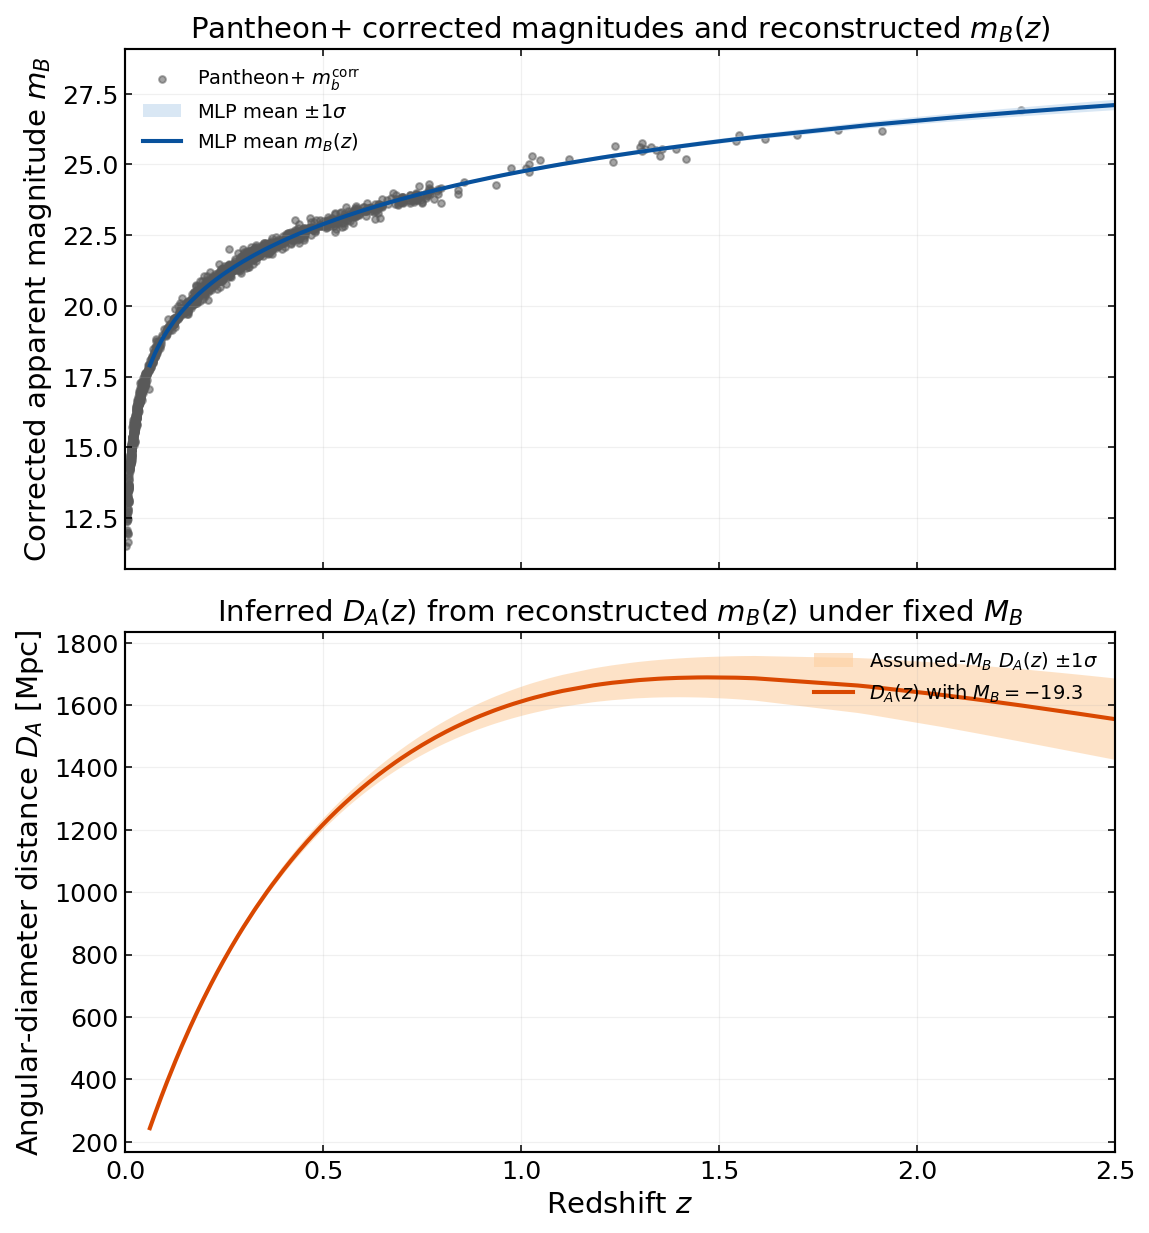

Assumed M_B = -19.3
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_mb_and_da_from_fixed_MB.png
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_mb_and_da_from_fixed_MB.pdf


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'legend.fontsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.1,
    'figure.dpi': 140,
})

project_dir = Path('/home/geng/Codes/sgl_cosmo/ann')
mb_result_dir = project_dir / 'output' / 'mb_ann_cov_161_weighted_run'
mb_csv_path = mb_result_dir / 'pantheon_mb_ann_reconstruction.csv'
data_path = project_dir / 'data' / 'Pantheon+SH0ES.dat'

mb_recon = pd.read_csv(mb_csv_path)
pantheon_mb = pd.read_csv(data_path, sep=r'\s+')
pantheon_mb = pantheon_mb.loc[pantheon_mb['IS_CALIBRATOR'] == 0].copy()

M_assumed = -19.3

mu_mean = mb_recon['m_b_mean'].to_numpy() - M_assumed
mu_sigma = mb_recon['m_b_sigma'].to_numpy()
dl_mpc_mean = 10 ** ((mu_mean - 25.0) / 5.0)
dl_mpc_sigma = (np.log(10.0) / 5.0) * dl_mpc_mean * mu_sigma
da_mpc_mean = dl_mpc_mean / (1.0 + mb_recon['z'].to_numpy()) ** 2
da_mpc_sigma = dl_mpc_sigma / (1.0 + mb_recon['z'].to_numpy()) ** 2

fig, axes = plt.subplots(2, 1, figsize=(8.4, 9.0), sharex=True)

axes[0].scatter(
    pantheon_mb['zHD'],
    pantheon_mb['m_b_corr'],
    s=12,
    color='0.35',
    alpha=0.55,
    label='Pantheon+ $m_b^{\\mathrm{corr}}$'
)
axes[0].fill_between(
    mb_recon['z'],
    mb_recon['m_b_mean'] - mb_recon['m_b_sigma'],
    mb_recon['m_b_mean'] + mb_recon['m_b_sigma'],
    color='#c6dbef',
    alpha=0.65,
    linewidth=0.0,
    label=r'MLP mean $\pm 1\sigma$',
)
axes[0].plot(mb_recon['z'], mb_recon['m_b_mean'], color='#08519c', lw=2.1, label=r'MLP mean $m_B(z)$')
axes[0].set_ylabel(r'Corrected apparent magnitude $m_B$')
axes[0].set_title(r'Pantheon+ corrected magnitudes and reconstructed $m_B(z)$')
axes[0].legend(frameon=False, loc='upper left')
axes[0].grid(alpha=0.18, linewidth=0.6)

axes[1].fill_between(
    mb_recon['z'],
    da_mpc_mean - da_mpc_sigma,
    da_mpc_mean + da_mpc_sigma,
    color='#fdd0a2',
    alpha=0.60,
    linewidth=0.0,
    label=r'Assumed-$M_B$ $D_A(z)$ $\pm 1\sigma$',
)
axes[1].plot(mb_recon['z'], da_mpc_mean, color='#d94801', lw=2.1, label=fr'$D_A(z)$ with $M_B={M_assumed:.1f}$')
axes[1].set_xlabel('Redshift $z$')
axes[1].set_ylabel(r'Angular-diameter distance $D_A$ [Mpc]')
axes[1].set_title(r'Inferred $D_A(z)$ from reconstructed $m_B(z)$ under fixed $M_B$')
axes[1].legend(frameon=False, loc='upper right')
axes[1].grid(alpha=0.18, linewidth=0.6)
axes[1].set_xlim(0.0, 2.5)

out_png = mb_result_dir / 'pantheon_mb_and_da_from_fixed_MB.png'
out_pdf = mb_result_dir / 'pantheon_mb_and_da_from_fixed_MB.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(f'Assumed M_B = {M_assumed:.1f}')
print(out_png)
print(out_pdf)

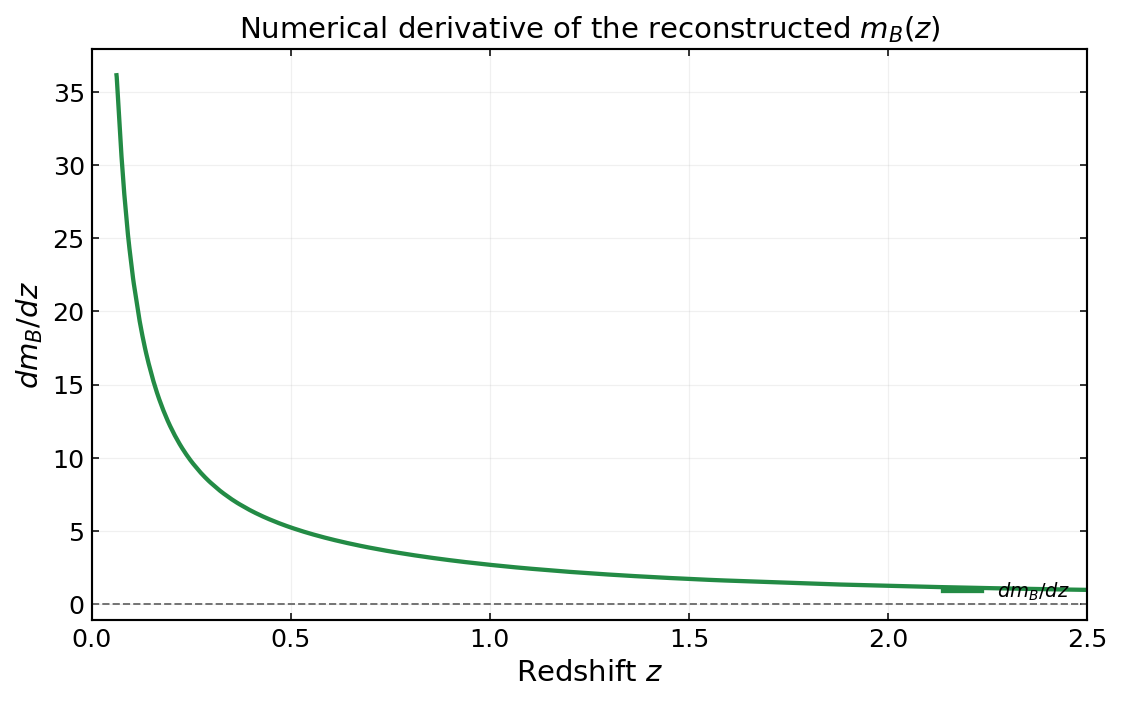

/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_mb_derivative.png
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_mb_derivative.pdf


In [ ]:
z_mb = mb_recon['z'].to_numpy()
mb_mean = mb_recon['m_b_mean'].to_numpy()
dmb_dz = np.gradient(mb_mean, z_mb)

fig, ax = plt.subplots(figsize=(8.2, 5.2))
ax.plot(z_mb, dmb_dz, color='#238b45', lw=2.2, label=r'$dm_B/dz$')
ax.axhline(0.0, color='0.45', lw=1.0, ls='--')
ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$dm_B/dz$')
ax.set_title(r'Numerical derivative of the reconstructed $m_B(z)$')
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.18, linewidth=0.6)

out_png = mb_result_dir / 'pantheon_mb_derivative.png'
out_pdf = mb_result_dir / 'pantheon_mb_derivative.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)

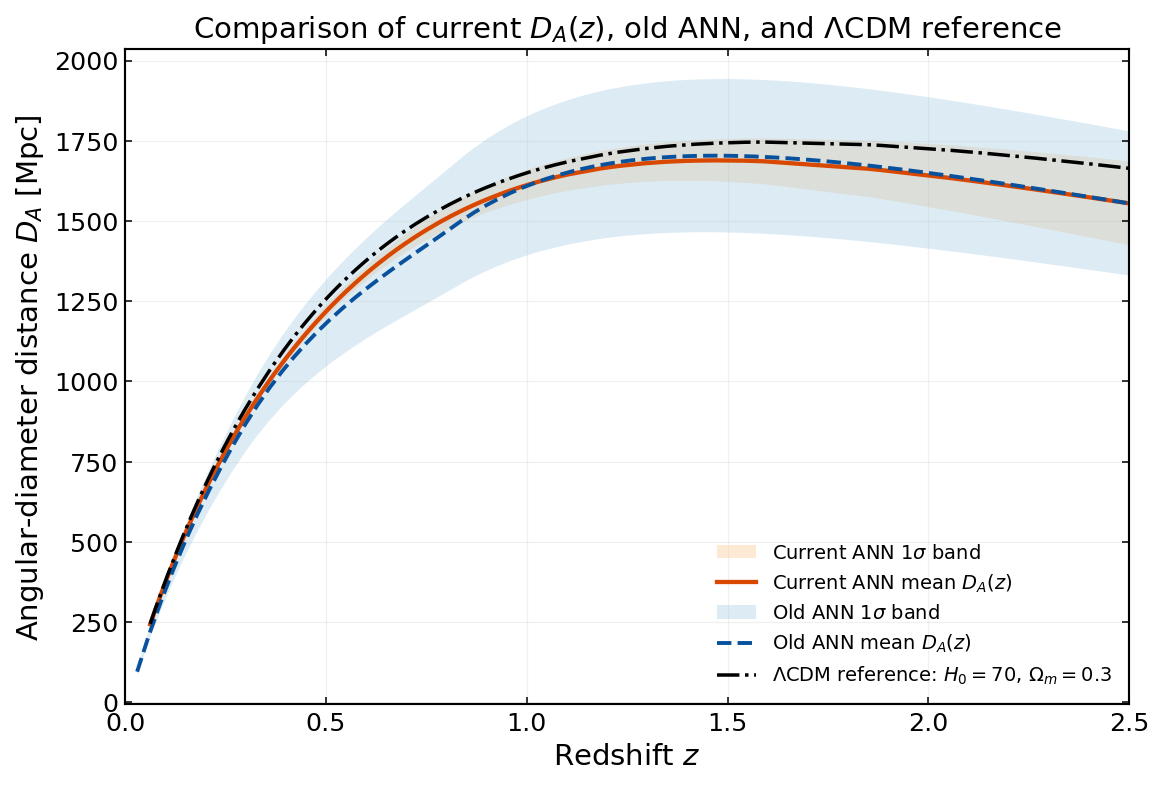

Assumed M_B = -19.3
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_current_old_model_da_comparison.png
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_current_old_model_da_comparison.pdf


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path('/home/geng/Codes/sgl_cosmo/ann')
mb_result_dir = project_dir / 'output' / 'mb_ann_cov_161_weighted_run'
mb_csv_path = mb_result_dir / 'pantheon_mb_ann_reconstruction.csv'
old_curve_path = project_dir / 'output' / 'old_ann' / 'rec_curve.npy'

mb_recon = pd.read_csv(mb_csv_path)
old_curve = np.load(old_curve_path)
old_z = old_curve[:, 0]
old_da = old_curve[:, 1]
old_da_sigma = old_curve[:, 2]

M_assumed = -19.3
new_z = mb_recon['z'].to_numpy()
new_mu = mb_recon['m_b_mean'].to_numpy() - M_assumed
new_mu_sigma = mb_recon['m_b_sigma'].to_numpy()
new_dl = 10 ** ((new_mu - 25.0) / 5.0)
new_dl_sigma = (np.log(10.0) / 5.0) * new_dl * new_mu_sigma
new_da = new_dl / (1.0 + new_z) ** 2
new_da_sigma = new_dl_sigma / (1.0 + new_z) ** 2

h0 = 70.0
omega_m = 0.3
omega_lambda = 1.0 - omega_m
c_km_s = 299792.458
e_z = np.sqrt(omega_m * (1.0 + new_z) ** 3 + omega_lambda)
integrand = 1.0 / e_z
dz = np.diff(new_z)
dc = np.empty_like(new_z)
dc[0] = (c_km_s / h0) * new_z[0] * integrand[0]
dc[1:] = (c_km_s / h0) * (
    dc[0] / (c_km_s / h0) + np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
)
lcdm_da = dc / (1.0 + new_z)

fig, ax = plt.subplots(figsize=(8.5, 5.8))

ax.fill_between(
    new_z,
    new_da - new_da_sigma,
    new_da + new_da_sigma,
    color='#fdd0a2',
    alpha=0.45,
    linewidth=0.0,
    label=r'Current ANN $1\sigma$ band',
)
ax.plot(new_z, new_da, color='#d94801', lw=2.2, label=r'Current ANN mean $D_A(z)$')

ax.fill_between(
    old_z,
    old_da - old_da_sigma,
    old_da + old_da_sigma,
    color='#9ecae1',
    alpha=0.35,
    linewidth=0.0,
    label=r'Old ANN $1\sigma$ band',
)
ax.plot(old_z, old_da, color='#08519c', lw=2.0, ls='--', label=r'Old ANN mean $D_A(z)$')

ax.plot(
    new_z,
    lcdm_da,
    color='black',
    lw=1.8,
    ls='-.',
    label=r'$\Lambda$CDM reference: $H_0=70$, $\Omega_m=0.3$',
)

ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'Angular-diameter distance $D_A$ [Mpc]')
ax.set_title(r'Comparison of current $D_A(z)$, old ANN, and $\Lambda$CDM reference')
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.18, linewidth=0.6)

out_png = mb_result_dir / 'pantheon_current_old_model_da_comparison.png'
out_pdf = mb_result_dir / 'pantheon_current_old_model_da_comparison.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(f'Assumed M_B = {M_assumed:.1f}')
print(out_png)
print(out_pdf)

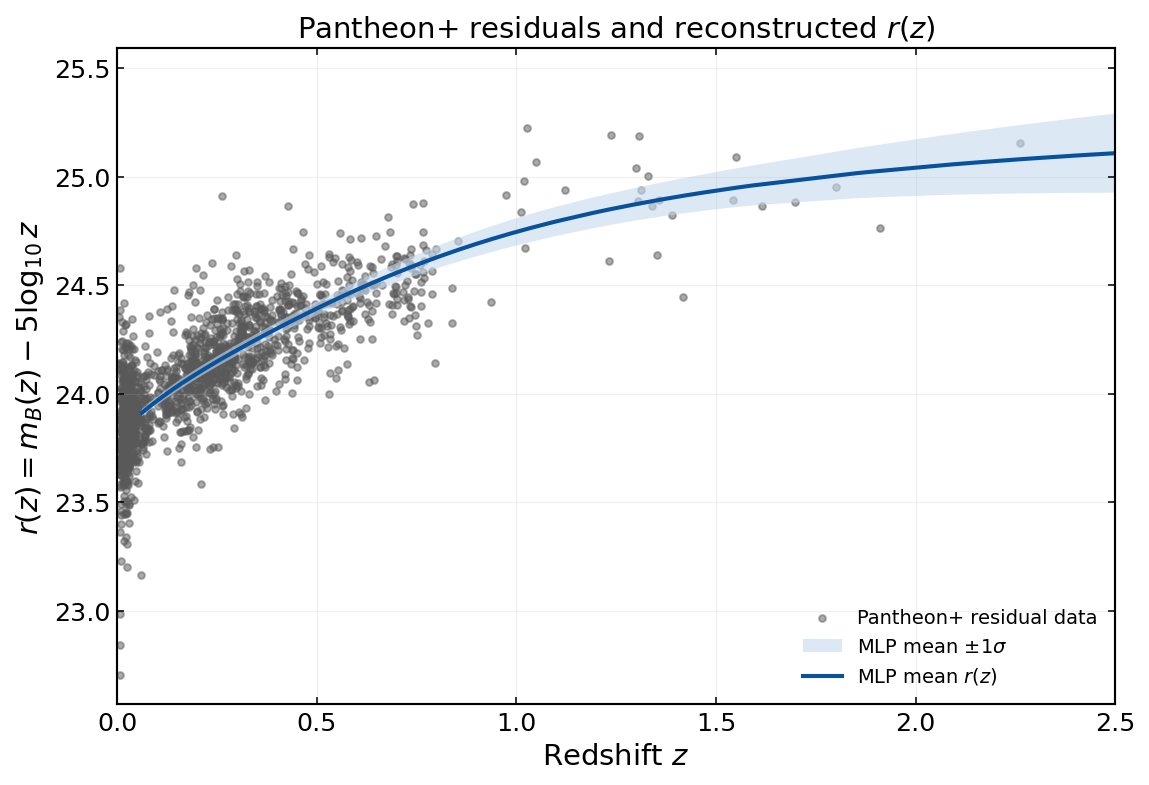

/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_rz_scatter_fit.png
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/pantheon_rz_scatter_fit.pdf


In [ ]:
r_data = pantheon_mb['m_b_corr'].to_numpy() - 5.0 * np.log10(pantheon_mb['zHD'].to_numpy())
r_mean = mb_recon['m_b_mean'].to_numpy() - 5.0 * np.log10(mb_recon['z'].to_numpy())
r_sigma = mb_recon['m_b_sigma'].to_numpy()

fig, ax = plt.subplots(figsize=(8.4, 5.8))

ax.scatter(
    pantheon_mb['zHD'],
    r_data,
    s=12,
    color='0.35',
    alpha=0.5,
    zorder=0,
    label='Pantheon+ residual data',
)
ax.fill_between(
    mb_recon['z'],
    r_mean - r_sigma,
    r_mean + r_sigma,
    color='#c6dbef',
    alpha=0.6,
    linewidth=0.0,
    label=r'MLP mean $\pm 1\sigma$',
)
ax.plot(
    mb_recon['z'],
    r_mean,
    color='#08519c',
    lw=2.1,
    label=r'MLP mean $r(z)$',
)

ax.set_xlim(0.0, 2.5)
ax.set_xlabel('Redshift $z$')
ax.set_ylabel(r'$r(z)=m_B(z)-5\log_{10} z$')
ax.set_title(r'Pantheon+ residuals and reconstructed $r(z)$')
ax.legend(frameon=False, loc='lower right')
ax.grid(alpha=0.18, linewidth=0.6)

out_png = mb_result_dir / 'pantheon_rz_scatter_fit.png'
out_pdf = mb_result_dir / 'pantheon_rz_scatter_fit.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)


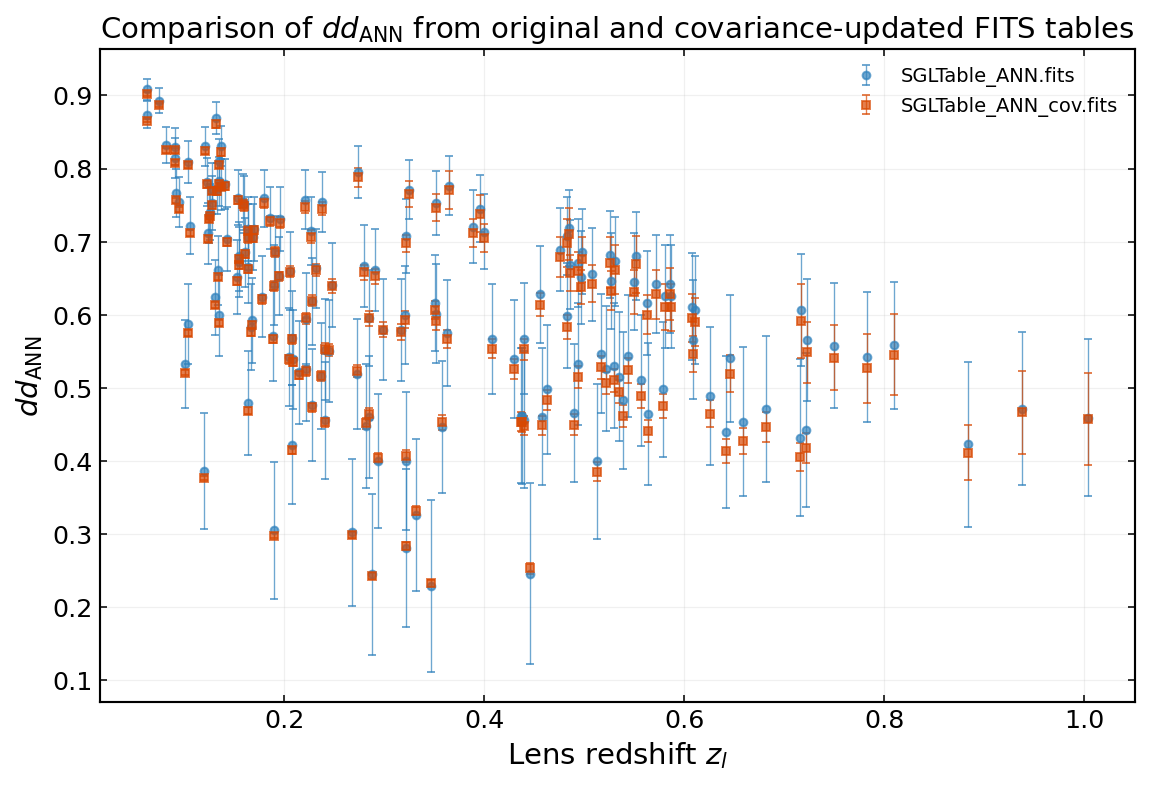

/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/sgl_dd_ann_fits_comparison.png
/home/geng/Codes/sgl_cosmo/ann/output/mb_ann_cov_161_weighted_run/sgl_dd_ann_fits_comparison.pdf


In [ ]:
from astropy.table import Table

fits_old = project_dir / 'data' / 'SGLTable_ANN.fits'
fits_cov = project_dir / 'data' / 'SGLTable_ANN_cov.fits'

table_old = Table.read(fits_old)
table_cov = Table.read(fits_cov)

fig, ax = plt.subplots(figsize=(8.4, 5.8))

ax.errorbar(
    table_old['zl'],
    table_old['dd_ANN'],
    yerr=table_old['dd_error_ANN'],
    fmt='o',
    ms=4.0,
    lw=0.8,
    elinewidth=0.7,
    capsize=2.0,
    color='#3182bd',
    alpha=0.7,
    label='SGLTable_ANN.fits',
)

ax.errorbar(
    table_cov['zl'],
    table_cov['dd_ANN'],
    yerr=table_cov['dd_error_ANN'],
    fmt='s',
    ms=3.8,
    lw=0.8,
    elinewidth=0.7,
    capsize=2.0,
    color='#d94801',
    alpha=0.7,
    label='SGLTable_ANN_cov.fits',
)

ax.set_xlabel(r'Lens redshift $z_l$')
ax.set_ylabel(r'$dd_{\mathrm{ANN}}$')
ax.set_title(r'Comparison of $dd_{\mathrm{ANN}}$ from original and covariance-updated FITS tables')
ax.grid(alpha=0.18, linewidth=0.6)
ax.legend(frameon=False, loc='best')

out_png = mb_result_dir / 'sgl_dd_ann_fits_comparison.png'
out_pdf = mb_result_dir / 'sgl_dd_ann_fits_comparison.pdf'
fig.tight_layout()
fig.savefig(out_png, bbox_inches='tight')
# fig.savefig(out_pdf, bbox_inches='tight')
plt.show()

print(out_png)
print(out_pdf)
